# IV - Machine Learning

## IV.3. Regression 🏡

Today we will focus on **Regression** problems - which means **Supervised** (with labeled data) and for **continuous data** (as opposed to Classification problems which work with labeled discrete data)

---

<img src="images/house.jpg" />

---

# I. Intuition

## I.1. Regression problems apply to *continuous* data

Regression problems apply to **continuous** data

Let's do a quiz and explore different problems to understand what we mean by **continuous** data.

> 🏆 **Quizz**: 
> 1. In ML, we always have input variable(s) and output variable(s). Does **continuous** refers to the input or the output?
> 2. If we want to predict the **age** of somebody, is the data **continuous** or **discrete**?
> 3. If we want to predict the **weather** tomorrow, is the data **continuous** or **discrete**?
> 4. If we want to predict the **phone number** of someone, is the data **continuous** or **discrete**?

## I.2. Linear Regression

Suppose we draw some points representing the price of a house along Y-axis, and the surface of that house along X-axis.

<img src="images/linear-regression.png" width="50%" align="center"/>

> 🏆 **Quizz**:
> - What would be the "best line" to represent this data?
> - What would be the equation representing this line?

House Price = 10000 * Surface + 5000

- `House Price` is the **target**
- `Surface` is the **input**
- `10000` is the **slope**
- `5000` is the **intercept**

**slope** and **intercept** are called the **parameters** of our model. These are the values that the model **learns** during training (iteratively).

Or, if you want to write it mathematically:
$$y = \theta_1 \times x + \theta_0$$

<img src="images/maths.gif" width="500px" align="center"/>

## I.3. Now time for predictions! 🔮

Imagine we are a house agent, listing properties and we need to price a new house that someone wants to sell.

Based on previous "best line" drawed, how much would we price a flat of 50m2? 

Congratulations! You just discovered **Linear Regression**, a super powerful yet simple algorithm for Regression models. Let's now implement it in `scikit-learn`.

---

# II. Easy to implement with [`scikit-learn`](https://scikit-learn.org)

Again, scikit-learn makes it very easy to create and train a Regression model in Python.

Lucky us! scikit-learn comes with a standard dataset containing real estate data (house characteristics and prices in Boston). 🏡

Let's load this dataset and visualize it on a 2D chart.

In [20]:
# We load Boston house prices
# Reference https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_boston.html
from sklearn.datasets import load_boston
X, y = load_boston(return_X_y=True)

# We keep only feature indexed 5 (corresponds to "Average Number of Rooms")
# for visualisation purposes
i = 5
X = X[:,i:i+1]

In [16]:
print("X.shape={}".format(X.shape))
print("y.shape={}".format(y.shape))

X.shape=(506, 1)
y.shape=(506,)


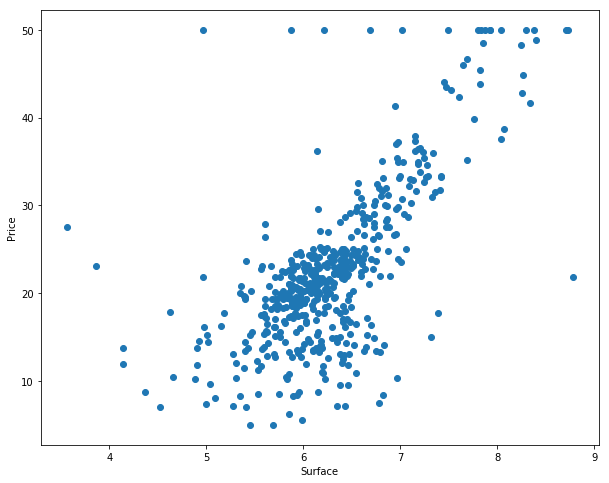

In [19]:
from matplotlib import pyplot as plt

# Create figure to draw chart
plt.figure(figsize=(10, 8))

# Plot the training points
plt.scatter(X, y)

# Format chart
plt.xlabel('Average Number of Rooms')
plt.ylabel('Price')
plt.show()

In [21]:
from sklearn.linear_model import LinearRegression 

# Create linear regression object
lr = LinearRegression()

In [22]:
# Train the model using only first feature of X (Surface)
lr.fit(X, y)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [24]:
# Make predictions based on train model
y_pred = lr.predict(X)

# Display coefficient and intercept
print('Coefficients: ', lr.coef_) # See how coefficients is in a list at it can contains multiple values
print('Intercept: ', lr.intercept_) # Intercept is a single value (always)

Coefficients:  [9.10210898]
Intercept:  -34.67062077643857


Let's now plot both the points used for training and the linear regression

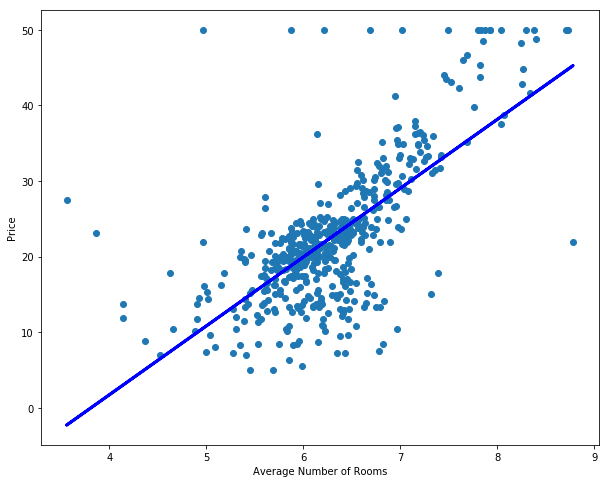

In [28]:
# Create figure to draw chart
plt.figure(2, figsize=(10, 8))

# Plot the training points
plt.scatter(X[:, 0], y)
plt.plot(X[:, 0], y_pred, color='blue', linewidth=3)

plt.xlabel('Average Number of Rooms')
plt.ylabel('Price')

plt.show()

---

# III. The learning process

This Linear Regression seems magical, we fit the scikit-learn object and automatically we retrieve the **best line** representing our data.

But what is happening under the hood?

## III.1. Intuition

<img src="images/linear-regression-errors.png" width="800px" align="center"/>

We search for the **parameters of the model** (here the slope and intersect) that minimize the **error** (also called **Cost Function**).

> 🔦 **Hint**: The distances (small bars) are called **residuals**, but in practice we prefer to sum the squares of residuals (so that it's always positive + the larger the distance the larger the error). 
>
> We call this sum the **[Residual Sum of Squares (RSS)](https://en.wikipedia.org/wiki/Residual_sum_of_squares)**

## III.2. Gradient Descent

We have a **Cost Function** (or **error**) that happens to be a bowl (how convenient) and we want to minimize it.

![image.png](images/bowl.png)

> 📚 **Resources**: We can demonstrate our Cost Function is "a bowl" be proving that the function is **[Convex](https://en.wikipedia.org/wiki/Convex_function)**

> 🏆 **Quizz**: How do we find those optimal parameters that minimize the Cost Function?

**Iteratively!**

Just like going down a mountain, you can get to the bottom of the valley by **going each step in the direction that makes you go down the most**.

Here we can do the same:
- We observe around us which direction makes us go down the most
- We make a step towards this direction
- We update our model with the new updated parameters
- And we iterate 🔄

<img src="images/gradient_descent_robot_on_bowl.jpg" />

This is called **Gradient Descent**

Here is an example of visualization of the evolution of our linear regression iteratively.


<img src="images/gradient-descent.gif" width="800px" align="center"/>

- On the left: our Cost Function and our position based on the chosen parameters (m and b)
- On the right: our data points and our linear regression model with updated parameters (m and b)

As you can see, on the left **at each iteration, we update the model parameters (intercept and slope)**, and this creates a **new line** even more fitted to our data. 

As we iterate on the model parameters, we go down our Cost Function until the **minimum error value**. 

This is **done automatically** when calling the **`fit`** method from scikit-learn! 🎩